In [15]:
import numpy as np
import math
import matplotlib.pyplot as plt
import time

# Các bản đồ

In [16]:
import numpy as np
grid30 = np.loadtxt('E:\last_dance\Last-dance\map\grid30.txt', dtype=np.int8)

# goals = [(4, 6), (4, 15), (16, 4), (12, 14), (20, 20), (20, 14), (23, 17), (17, 15)]
goals = [(4, 6), (12, 14), (18, 10)]
for goal in goals:
    grid30[goal] = 2

grid = grid30
n = grid.shape[0]

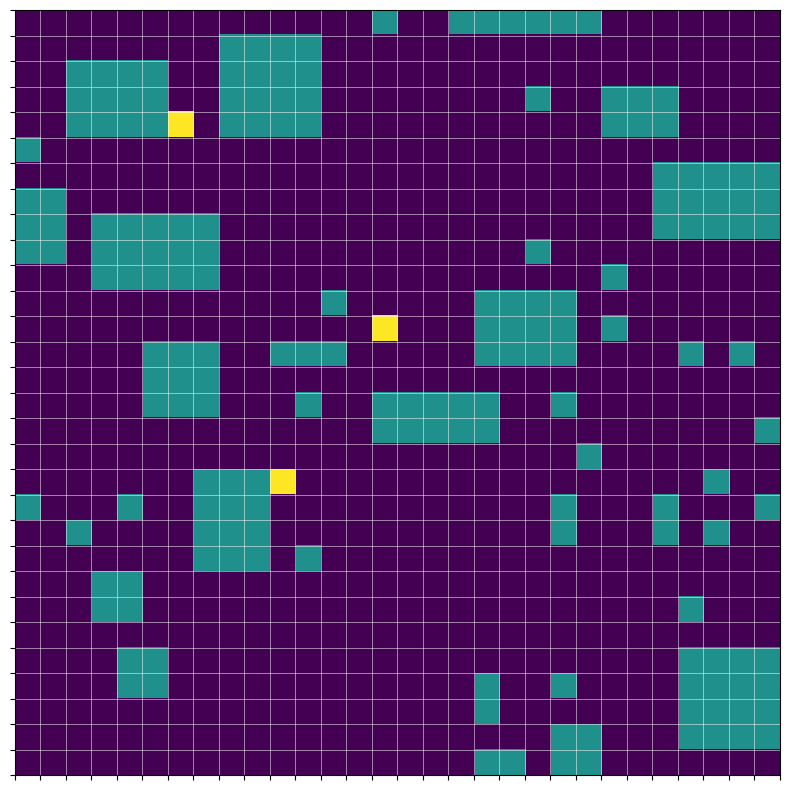

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Trực quan hóa đường đi Q-Learning
fig, ax = plt.subplots(figsize=(8, 8))

# Vẽ bản đồ (0=free, 1=obstacle)
# Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

# ======= THÊM LƯỚI Ô NGUYÊN  =======
n, m = grid.shape
ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
ax.set_aspect('equal')
ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')


plt.tight_layout()
# out_path_q = "/mnt/data/q_learning_path.png"
# plt.savefig(out_path_q, dpi=180)
plt.show() # Hiển thị biểu đồ đường đi Q-Learning
# plt.close(fig)
# print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

In [18]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_path(grid, path, mandatory_waypoints):
    if path:
        print("\nĐường đi được trích xuất từ bảng Q:")
        print(path)
        L_q = path_length(path)
        print("Độ dài đường đi:", round(L_q, 3))

        # Trực quan hóa đường đi Q-Learning
        print("\nĐang trực quan hóa đường đi Q-Learning...")
        fig, ax = plt.subplots(figsize=(8, 8))

        # Vẽ bản đồ (0=free, 1=obstacle)
        # Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
        im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

        # Vẽ đường đi theo từng bước
        xs = [p[1] for p in path] # Hoán đổi x và y để vẽ
        ys = [p[0] for p in path] # Hoán đổi x và y để vẽ
        ax.plot(xs, ys, linewidth=2, color="red", zorder=3) # Sử dụng màu khác cho đường đi Q
        ax.scatter([path[0][1], path[-1][1]], # Hoán đổi x và y để vẽ
                [path[0][0], path[-1][0]], # Hoán đổi x và y để vẽ
                marker='x', s=160, linewidths=2.5, color="red", zorder=4)

        # Vẽ các điểm bắt buộc
        mandatory_wp_x = [wp[1] for wp in mandatory_waypoints]
        mandatory_wp_y = [wp[0] for wp in mandatory_waypoints]
        ax.scatter(mandatory_wp_x, mandatory_wp_y, marker='o', s=100, linewidths=2.5, color="blue", zorder=5, label="Điểm bắt buộc")

        # ======= THÊM LƯỚI Ô NGUYÊN  =======
        n, m = grid.shape
        ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
        ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')

        ax.set_title(f"Đường đi có độ dài={L_q:.2f}, số bước={len(path)-1}")
        ax.legend()

        plt.tight_layout()
        # out_path_q = "/mnt/data/q_learning_path.png"
        # plt.savefig(out_path_q, dpi=180)
        plt.show() # Hiển thị biểu đồ đường đi Q-Learning
        # plt.close(fig)
        # print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

    else:
        print("\nKhông thể trích xuất đường đi hợp lệ từ bảng Q.")

# DP

In [19]:
# Kiểm tra điểm có nằm trong lưới không
def in_bounds(p, n, m):
    return 0 <= p[0] < n and 0 <= p[1] < m

# ---------- helpers ----------
MOVES8 = [(-1,-1), (-1,0), (-1,1),
          ( 0,-1),          ( 0,1),
          ( 1,-1), ( 1,0),  ( 1,1)]

# Hàm khoảng cách Euclid giữa hai điểm
def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

# Tính độ dài đường đi
def path_length(path):
    if not path or len(path) < 2:
        return 0.0
    return sum(euclid(path[i], path[i + 1]) for i in range(len(path) - 1))

In [20]:
# Tạo sub_grid từ start_point đến end_point
def create_sub_grid(start_point, end_point, grid):
    x_min = min(start_point[0], end_point[0])
    x_max = max(start_point[0], end_point[0])
    y_min = min(start_point[1], end_point[1])
    y_max = max(start_point[1], end_point[1])
    
    return grid[x_min:x_max+1, y_min:y_max+1]

In [21]:
# test create_sub_grid
start_point = (4, 20)
end_point = (12, 14)
sub_grid = create_sub_grid(start_point, end_point, grid)
print("Sub-grid:\n", sub_grid)

Sub-grid:
 [[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1]
 [2 0 0 0 1 1 1]]


In [22]:
def find_path_segment_down_right(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][0] = 0

    for i in range(1, n):
        if sub_grid[i][0] != 1:
            d[i][0] = min(d[i][0], d[i-1][0] + 1)

    for j in range(1, m):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j-1] + 1)

    for i in range(1, n):
        for j in range(1, m):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j-1] + 1,          # đi sang phải
                    d[i-1][j-1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][m-1])

    # B2: truy vết đường đi từ (n-1, m-1) về (0,0)
    path = []
    i, j = n-1, m-1

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
    else:
        while not (i == 0 and j == 0):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, trái (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, -1, math.sqrt(2)), (-1, 0, 1), (0, -1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj < 0:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, 0))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]

        return path, d[n-1][m-1]

In [23]:
def find_path_segment_down_left(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][m-1] = 0

    for i in range(1, n):
        if sub_grid[i][m-1] != 1:
            d[i][m-1] = min(d[i][m-1], d[i-1][m-1] + 1)

    for j in range(m-2, -1, -1):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j+1] + 1)

    for i in range(1, n):
        for j in range(m-2, -1, -1):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j+1] + 1,          # đi sang trái
                    d[i-1][j+1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][0])

    # B2: truy vết đường đi từ (n-1, 0) về (0,m-1)
    path = []
    i, j = n-1, 0

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
    else:
        while not (i == 0 and j == m-1):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, phải (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, 1, math.sqrt(2)), (-1, 0, 1), (0, 1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj >= m:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, m-1))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]
        return path, d[n-1][0]

In [24]:
# test find_path_segment_down_right
start_point = (4, 6)
end_point = (12, 14)
path, length = find_path_segment_down_right(start_point, end_point, grid)
print("Đường đi:", path)
print("Độ dài đường đi:", length)

Độ dài đường đi ngắn nhất tới đích: 11.313708498984763
Đường đi: [(4, 6), (5, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12), (11, 13), (12, 14)]
Độ dài đường đi: 11.313708498984763


In [25]:
# test find_path_segment_down_left
start_point = (4, 20)
end_point = (12, 14)
path, length = find_path_segment_down_left(start_point, end_point, grid)
print("Đường đi:", path)
print("Độ dài đường đi:", length)

Độ dài đường đi ngắn nhất tới đích: 10.485281374238571
Đường đi: [(4, 20), (5, 20), (6, 20), (7, 19), (8, 18), (9, 17), (10, 16), (11, 15), (12, 14)]
Độ dài đường đi: 10.485281374238571


In [26]:
# Hàm chính để tìm đường đi ngắn nhất qua các điểm bắt buộc
def find_shortest_path_with_mandatory_waypoints(grid_map, start_node, end_node, mandatory_waypoints):
    # Sắp xếp các điểm bắt buộc để đảm bảo di chuyển xuống và sang phải
    # Nếu không sắp xếp, có thể có trường hợp không tìm được đường đi với ràng buộc này
    sorted_waypoints = sorted(mandatory_waypoints)

    # Tạo danh sách tất cả các điểm cần đi qua theo thứ tự: Start -> Waypoints (sắp xếp) -> End
    all_points = [start_node] + sorted_waypoints + [end_node]

    total_path = []
    total_length = 0.0

    # Duyệt qua từng đoạn đường giữa các điểm liên tiếp
    for i in range(len(all_points) - 1):
        segment_start = all_points[i]
        segment_end = all_points[i+1]

        print(f"Đang tìm đường đi từ {segment_start} đến {segment_end}...")
        if segment_start[0] <= segment_end[0] and segment_start[1] <= segment_end[1]:
            # Di chuyển xuống và sang phải
            current_segment_path, current_segment_length = find_path_segment_down_right(segment_start, segment_end, grid_map)
        elif segment_start[0] <= segment_end[0] and segment_start[1] >= segment_end[1]:
            # Di chuyển xuống và sang trái
            current_segment_path, current_segment_length = find_path_segment_down_left(segment_start, segment_end, grid_map)

        if current_segment_length > 1e9: # Nếu không tìm thấy đường đi cho một đoạn
            print(f"Không tìm thấy đường đi hợp lệ từ {segment_start} đến {segment_end}. Toàn bộ đường đi không khả dụng.")
            return [], 1e10 # Trả về lỗi nếu bất kỳ đoạn nào không tìm thấy

        # Nối đoạn đường hiện tại vào tổng đường đi
        # Tránh lặp lại điểm cuối của đoạn trước (điểm bắt đầu của đoạn hiện tại)
        if i > 0:
            total_path.extend(current_segment_path[1:])
        else:
            total_path.extend(current_segment_path)

        total_length += current_segment_length

    return total_path, total_length

In [27]:
# --- Thực thi chính ---
start_exec_time = time.time()

start_node = (0, 0)
end_node = (n-1, n-1)

# Trích xuất các điểm bắt buộc (giá trị 2) từ bản đồ
mandatory_waypoints = []
for r in range(n):
    for c in range(n):
        if grid[r][c] == 2:
            mandatory_waypoints.append((r, c))

print(f"Các điểm bắt buộc phải đi qua được tìm thấy: {mandatory_waypoints}")
if not mandatory_waypoints:
    print("Không có điểm bắt buộc nào (số 2) trên bản đồ. Giải thuật sẽ tìm đường đi từ (0,0) đến (n-1,n-1) bình thường.")
    # Fallback to original single-segment path if no waypoints
    path, L_q = find_path_segment_down_right(start_node, end_node, grid)
else:
    path, L_q = find_shortest_path_with_mandatory_waypoints(grid, start_node, end_node, mandatory_waypoints)

end_exec_time = time.time()

if L_q > 1e9:
    print("Không tìm thấy đường đi hợp lệ bao gồm tất cả các điểm bắt buộc.")
else:
    print(f"\nĐộ dài đường đi ngắn nhất qua tất cả các điểm bắt buộc: {L_q:.2f}")
    print("Đường đi (theo thứ tự):")
    # For very long paths, printing all might be excessive, but for 30x30, it's ok.
    for cell in path:
        print(cell)

print(f"Thời gian chạy: {end_exec_time - start_exec_time:.6f} giây")

Các điểm bắt buộc phải đi qua được tìm thấy: [(4, 6), (12, 14), (18, 10)]
Đang tìm đường đi từ (0, 0) đến (4, 6)...
Độ dài đường đi ngắn nhất tới đích: 8.82842712474619
Đang tìm đường đi từ (4, 6) đến (12, 14)...
Độ dài đường đi ngắn nhất tới đích: 11.313708498984763
Đang tìm đường đi từ (12, 14) đến (18, 10)...
Độ dài đường đi ngắn nhất tới đích: 7.65685424949238
Đang tìm đường đi từ (18, 10) đến (29, 29)...
Độ dài đường đi ngắn nhất tới đích: 23.55634918610405

Độ dài đường đi ngắn nhất qua tất cả các điểm bắt buộc: 51.36
Đường đi (theo thứ tự):
(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(1, 5)
(2, 6)
(3, 6)
(4, 6)
(5, 7)
(6, 8)
(7, 9)
(8, 10)
(9, 11)
(10, 12)
(11, 13)
(12, 14)
(13, 14)
(14, 14)
(15, 13)
(16, 12)
(17, 11)
(18, 10)
(18, 11)
(18, 12)
(18, 13)
(18, 14)
(18, 15)
(19, 16)
(20, 17)
(21, 18)
(22, 19)
(23, 20)
(24, 21)
(25, 22)
(26, 23)
(27, 24)
(28, 25)
(29, 26)
(29, 27)
(29, 28)
(29, 29)
Thời gian chạy: 0.001788 giây



Đường đi được trích xuất từ bảng Q:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 5), (2, 6), (3, 6), (4, 6), (5, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12), (11, 13), (12, 14), (13, 14), (14, 14), (15, 13), (16, 12), (17, 11), (18, 10), (18, 11), (18, 12), (18, 13), (18, 14), (18, 15), (19, 16), (20, 17), (21, 18), (22, 19), (23, 20), (24, 21), (25, 22), (26, 23), (27, 24), (28, 25), (29, 26), (29, 27), (29, 28), (29, 29)]
Độ dài đường đi: 51.355

Đang trực quan hóa đường đi Q-Learning...


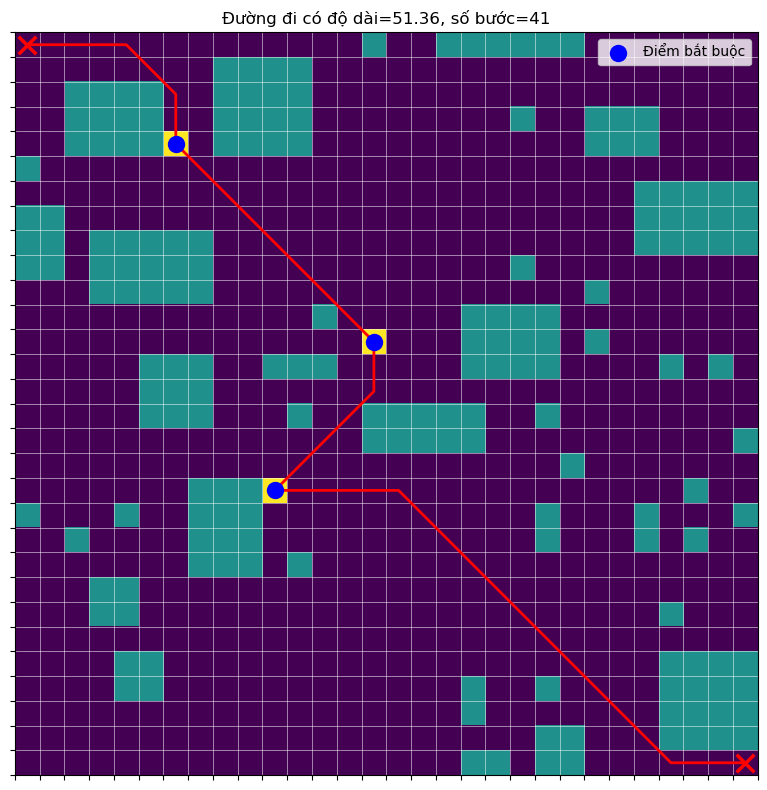

In [28]:
visualize_path(grid, path, mandatory_waypoints)